# RNA QUBO results analysis

This notebook reads the saved execution outputs, builds run- and length-level summaries, produces the main figures, and performs paired comparisons between QUBO variants. It does not generate sequences, build QUBOs, optimize QAOA parameters, or submit hardware jobs.


## 1. Colab setup
*For submission and github repository, Colab setup cells will be removed. Configure your environment here*

In [ ]:
%pip install -q ViennaRNA qiskit-optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 10.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00


## 2. Imports, paths, and analysis settings


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from analysis import (
    aggregate_length_statistics,
    build_per_run_summary,
    plot_metric_by_length,
)

In [ ]:
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_SEQUENCES_PATH = RESULTS_DIR / "selected_sequences.csv"
MODEL_COMPLEXITY_PATH = RESULTS_DIR / "model_complexity.csv"
DETAILED_RESULTS_PATH = RESULTS_DIR / "detailed_results.csv"
RUN_METADATA_PATH = RESULTS_DIR / "run_metadata.csv"
FAILURES_PATH = RESULTS_DIR / "failures.csv"
LENGTH_SUMMARY_PATH = RESULTS_DIR / "length_summary.csv"

SAVE_FIGURES = True
FIGURE_DPI = 150

## 3. Load and validate execution outputs


In [ ]:
required_paths = [
    SELECTED_SEQUENCES_PATH,
    MODEL_COMPLEXITY_PATH,
    DETAILED_RESULTS_PATH,
    RUN_METADATA_PATH,
]
missing_paths = [path for path in required_paths if not path.exists()]

if missing_paths:
    raise FileNotFoundError(
        "Missing required execution outputs:\n"
        + "\n".join(str(path) for path in missing_paths)
    )

all_selected_sequences_df = pd.read_csv(SELECTED_SEQUENCES_PATH)
model_complexity_df = pd.read_csv(MODEL_COMPLEXITY_PATH)
all_detailed_results_df = pd.read_csv(DETAILED_RESULTS_PATH)
run_metadata_df = pd.read_csv(RUN_METADATA_PATH)
failures_df = pd.read_csv(FAILURES_PATH) if FAILURES_PATH.exists() else pd.DataFrame()

simulation_selection_df = all_selected_sequences_df[
    all_selected_sequences_df["selected_for_simulation"]
].copy()
hardware_selection_df = all_selected_sequences_df[
    all_selected_sequences_df["selected_for_hardware"]
].copy()


In [ ]:
required_columns = {
    "selected sequences": {
        "sequence_id",
        "length",
        "num_candidate_stems",
        "selected_for_simulation",
        "selected_for_hardware",
    },
    "model complexity": {
        "sequence_id",
        "length",
        "variant",
        "selected_for_simulation",
        "selected_for_hardware",
        "num_variables",
        "num_quadratic_terms",
    },
    "detailed results": {
        "sequence_id",
        "length",
        "variant",
        "backend_mode",
        "backend_name",
        "run_id",
        "run_seed",
        "candidate_structure",
        "sample_rank",
        "sample_probability",
        "raw_valid",
        "stems_removed_by_repair",
        "energy_gap",
        "pair_f1",
        "num_variables",
        "num_quadratic_terms",
        "num_qubits",
        "circuit_depth",
        "sampling_runtime_seconds",
    },
    "run metadata": {
        "sequence_id",
        "length",
        "variant",
        "backend_mode",
        "backend_name",
        "run_id",
        "sampling_runtime_seconds",
    },
}

dataframes = {
    "selected sequences": all_selected_sequences_df,
    "model complexity": model_complexity_df,
    "detailed results": all_detailed_results_df,
    "run metadata": run_metadata_df,
}

for name, columns in required_columns.items():
    missing = sorted(columns - set(dataframes[name].columns))
    if missing:
        raise ValueError(f"{name} is missing columns: {', '.join(missing)}")

print("Required columns are present.")


Required columns are present.


## 4. Run and length summaries

Probability-weighted validity and repair metrics are calculated over the retained objective-ranked candidates. `retained_probability_mass` shows how much of the measured distribution those candidates represent.


In [ ]:
per_run_summary_df = build_per_run_summary(all_detailed_results_df)
length_summary_df = aggregate_length_statistics(per_run_summary_df)
length_summary_df.to_csv(LENGTH_SUMMARY_PATH, index=False)

per_run_columns = [
    "sequence_id",
    "length",
    "variant",
    "backend_mode",
    "run_id",
    "energy_gap",
    "pair_f1",
    "probability_weighted_raw_validity",
    "probability_weighted_stems_removed",
    "retained_probability_mass",
    "num_variables",
    "num_quadratic_terms",
    "num_qubits",
    "circuit_depth",
]
length_columns = [
    "length",
    "variant",
    "backend_mode",
    "num_sequences",
    "mean_num_variables",
    "mean_num_quadratic_terms",
    "mean_num_qubits",
    "mean_weighted_raw_validity",
    "mean_weighted_stems_removed",
    "mean_retained_probability_mass",
    "mean_energy_gap",
    "mean_pair_f1",
    "mean_circuit_depth",
    "mean_sampling_seconds",
]

display(per_run_summary_df[per_run_columns].head(5))
display(length_summary_df[length_columns].head(5))
print(f"Length summary saved to {LENGTH_SUMMARY_PATH}")


,sequence_id,length,variant,backend_mode,run_id,energy_gap,pair_f1,probability_weighted_raw_validity,probability_weighted_stems_removed,retained_probability_mass,num_variables,num_quadratic_terms,num_qubits,circuit_depth
0,synth_000001,10,postprocessed,aer,aer_run_01_seed_666,5.0,0.0,0.000000,1.999023,1.0,3,0,3,2
1,synth_000001,10,relaxed,aer,aer_run_01_seed_666,0.0,1.0,0.562988,0.443359,1.0,3,2,3,6
2,synth_000001,10,strict,aer,aer_run_01_seed_666,0.0,1.0,0.751953,0.310547,1.0,3,3,3,6
3,synth_000002,10,postprocessed,aer,aer_run_01_seed_666,2.0,0.0,0.000000,1.999023,1.0,3,0,3,2
4,synth_000002,10,relaxed,aer,aer_run_01_seed_666,0.0,1.0,0.073242,1.534180,1.0,3,1,3,4


,length,variant,backend_mode,num_sequences,mean_num_variables,mean_num_quadratic_terms,mean_num_qubits,mean_weighted_raw_validity,mean_weighted_stems_removed,mean_retained_probability_mass,mean_energy_gap,mean_pair_f1,mean_circuit_depth,mean_sampling_seconds
0,10,postprocessed,aer,30,1.600000,0.0,1.600000,0.500391,0.599512,1.0,2.833333,0.000000,2.0,0.006363
1,12,postprocessed,aer,30,3.700000,0.0,3.700000,0.169417,2.330599,1.0,1.983333,0.166667,2.0,0.008309
2,14,postprocessed,aer,30,4.700000,0.0,4.700000,0.070703,3.268701,1.0,2.023333,0.200000,2.0,0.007267
3,16,postprocessed,aer,30,7.566667,0.0,7.566667,0.100260,5.347591,1.0,1.020000,0.466667,2.0,0.010085
4,18,postprocessed,aer,30,11.733333,0.0,11.733333,0.000065,8.666520,1.0,1.686667,0.295238,2.0,0.015699


Length summary saved to /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/data/results/length_summary.csv


In [ ]:
coverage_df = (
    per_run_summary_df.groupby(["length", "variant", "backend_mode"])
    .agg(
        represented_sequences=("sequence_id", "nunique"),
        represented_runs=("run_id", "size"),
    )
    .reset_index()
)
display(coverage_df)

if failures_df.empty:
    print("No failures were recorded.")
else:
    failure_summary_df = (
        failures_df.groupby(
            ["stage", "length", "variant", "error_type"],
            dropna=False,
        )
        .size()
        .rename("failure_count")
        .reset_index()
    )
    display(failure_summary_df)


,length,variant,backend_mode,represented_sequences,represented_runs
0,10,postprocessed,aer,30,30
1,10,postprocessed,ibm,15,15
2,10,relaxed,aer,30,30
3,10,relaxed,ibm,15,15
4,10,strict,aer,30,30
5,10,strict,ibm,15,15
6,12,postprocessed,aer,30,30
7,12,relaxed,aer,30,30
8,12,strict,aer,30,30
9,14,postprocessed,aer,30,30


No failures were recorded.


## 5. Plot helpers and model-complexity summaries


In [ ]:
def save_figure(fig, filename):
    if SAVE_FIGURES:
        path = FIGURES_DIR / filename
        fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
        print(f"Saved figure: {path}")


In [ ]:
complexity_parts = []

for backend_mode, backend_name, selection_column in [
    ("aer", "Aer selection", "selected_for_simulation"),
    ("ibm", "IBM selection", "selected_for_hardware"),
]:
    selected_complexity_df = model_complexity_df[
        model_complexity_df[selection_column]
    ]

    if selected_complexity_df.empty:
        continue

    summary_df = (
        selected_complexity_df.groupby(["length", "variant"], as_index=False)
        .agg(
            mean_num_variables=("num_variables", "mean"),
            std_num_variables=("num_variables", "std"),
            mean_num_quadratic_terms=("num_quadratic_terms", "mean"),
            std_num_quadratic_terms=("num_quadratic_terms", "std"),
        )
    )
    summary_df["backend_mode"] = backend_mode
    summary_df["backend_name"] = backend_name
    complexity_parts.append(summary_df)

model_complexity_summary_df = pd.concat(complexity_parts, ignore_index=True)
display(model_complexity_summary_df.head(12))


,length,variant,mean_num_variables,std_num_variables,mean_num_quadratic_terms,std_num_quadratic_terms,backend_mode,backend_name
0,10,postprocessed,1.600000,0.674665,0.000000,0.000000,aer,Aer selection
1,10,relaxed,1.600000,0.674665,0.566667,0.727932,aer,Aer selection
2,10,strict,1.600000,0.674665,0.700000,0.915386,aer,Aer selection
3,12,postprocessed,3.700000,1.784029,0.000000,0.000000,aer,Aer selection
4,12,relaxed,3.700000,1.784029,5.400000,5.082763,aer,Aer selection
5,12,strict,3.700000,1.784029,6.466667,5.727931,aer,Aer selection
6,14,postprocessed,4.700000,2.465626,0.000000,0.000000,aer,Aer selection
7,14,relaxed,4.700000,2.465626,8.700000,8.209120,aer,Aer selection
8,14,strict,4.700000,2.465626,11.233333,10.351356,aer,Aer selection
9,16,postprocessed,7.566667,3.953901,0.000000,0.000000,aer,Aer selection


## 6. QUBO size and structural-quality figures


Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/01_candidate_stem_growth.png


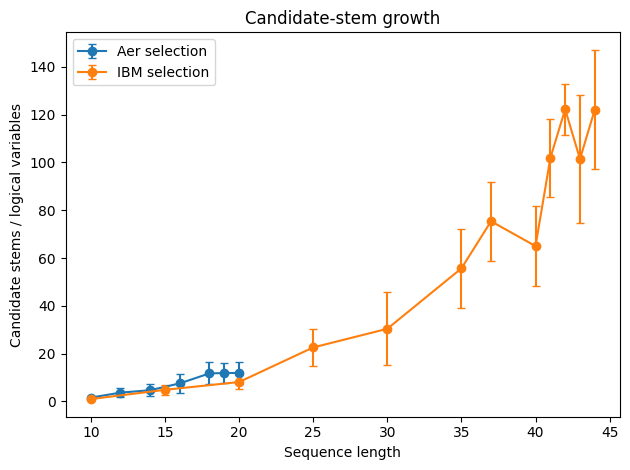

In [ ]:
selection_size_frames = []

for selection_name, selection_df in [
    ("Aer selection", simulation_selection_df),
    ("IBM selection", hardware_selection_df),
]:
    if selection_df.empty:
        continue

    summary_df = (
        selection_df.groupby("length")
        .agg(
            mean_candidate_stems=("num_candidate_stems", "mean"),
            std_candidate_stems=("num_candidate_stems", "std"),
        )
        .reset_index()
    )
    summary_df["selection"] = selection_name
    selection_size_frames.append(summary_df)

selected_size_summary_df = pd.concat(selection_size_frames, ignore_index=True)
fig, ax = plt.subplots()

for selection_name, group_df in selected_size_summary_df.groupby(
    "selection",
    sort=False,
):
    group_df = group_df.sort_values("length")
    ax.errorbar(
        group_df["length"],
        group_df["mean_candidate_stems"],
        yerr=group_df["std_candidate_stems"].fillna(0.0),
        marker="o",
        capsize=3,
        label=selection_name,
    )

ax.set_xlabel("Sequence length")
ax.set_ylabel("Candidate stems / logical variables")
ax.set_title("Candidate-stem growth")
ax.legend()
fig.tight_layout()
save_figure(fig, "01_candidate_stem_growth.png")
plt.show()


Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/02a_aer_qubo_interaction_growth.png


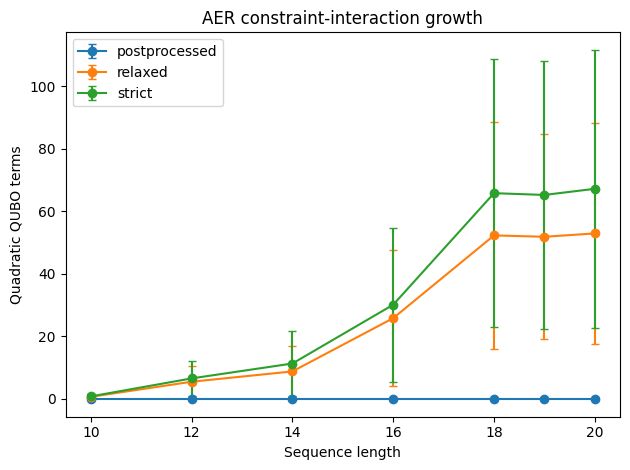

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/02b_ibm_qubo_interaction_growth.png


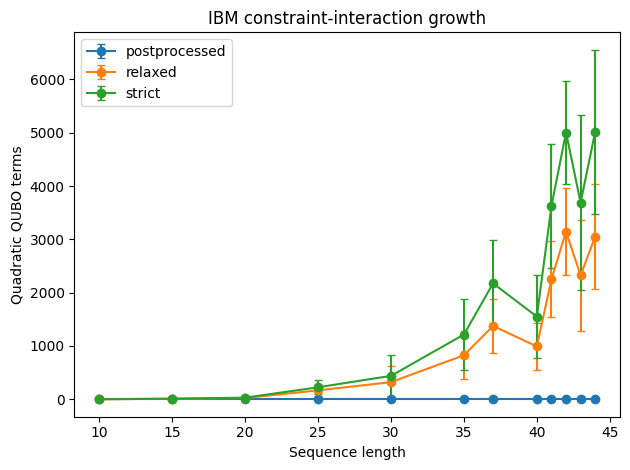

In [ ]:
for backend_mode, filename in [
    ("aer", "02a_aer_qubo_interaction_growth.png"),
    ("ibm", "02b_ibm_qubo_interaction_growth.png"),
]:

    fig, ax = plot_metric_by_length(
        model_complexity_summary_df,
        mean_column="mean_num_quadratic_terms",
        std_column="std_num_quadratic_terms",
        y_label="Quadratic QUBO terms",
        title=f"{backend_mode.upper()} constraint-interaction growth",
        backend_modes=(backend_mode,),
    )
    save_figure(fig, filename)
    plt.show()


Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/03_raw_validity.png


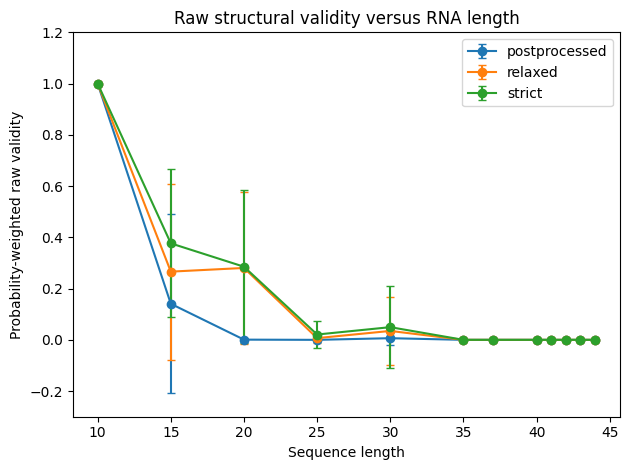

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/04_repair_burden.png


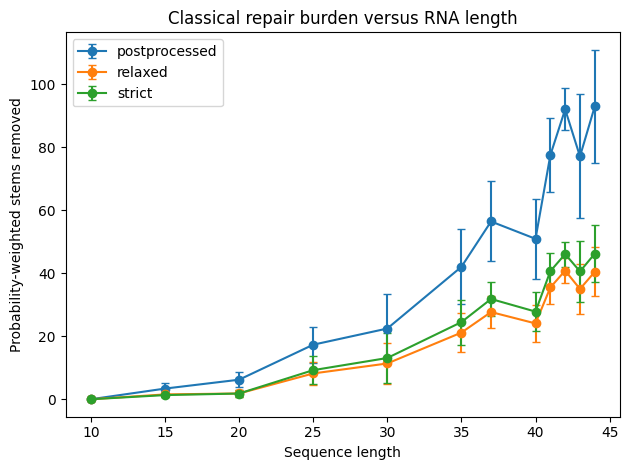

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/05_energy_gap.png


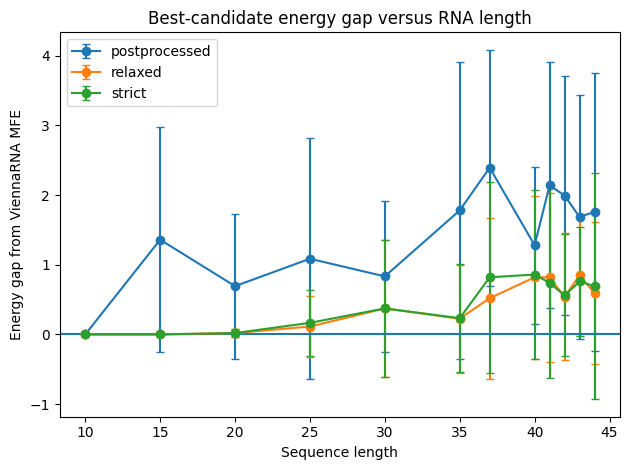

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/06_pair_f1.png


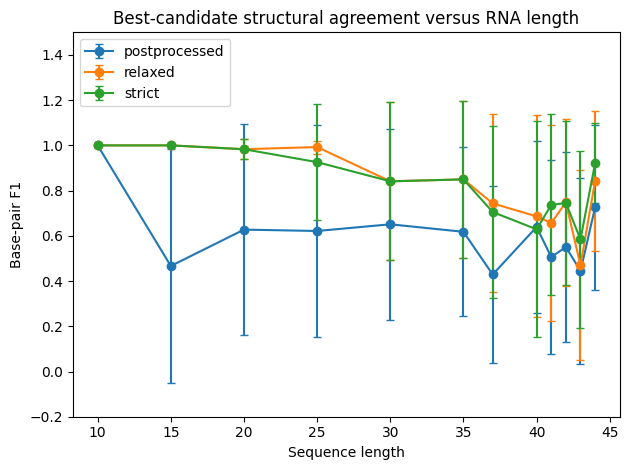

In [ ]:
ibm_length_summary_df = length_summary_df[
    length_summary_df["backend_mode"] == "ibm"
]

plot_specs = [
    (
        "mean_weighted_raw_validity",
        "std_weighted_raw_validity",
        "Probability-weighted raw validity",
        "Raw structural validity versus RNA length",
        "03_raw_validity.png",
        (-0.3, 1.2),
    ),
    (
        "mean_weighted_stems_removed",
        "std_weighted_stems_removed",
        "Probability-weighted stems removed",
        "Classical repair burden versus RNA length",
        "04_repair_burden.png",
        None,
    ),
    (
        "mean_energy_gap",
        "std_energy_gap",
        "Energy gap from ViennaRNA MFE",
        "Best-candidate energy gap versus RNA length",
        "05_energy_gap.png",
        None,
    ),
    (
        "mean_pair_f1",
        "std_pair_f1",
        "Base-pair F1",
        "Best-candidate structural agreement versus RNA length",
        "06_pair_f1.png",
        (-0.2, 1.5),
    ),
]

for mean_column, std_column, y_label, title, filename, y_limits in plot_specs:
    fig, ax = plot_metric_by_length(
        length_summary_df,
        mean_column=mean_column,
        std_column=std_column,
        y_label=y_label,
        title=title,
        backend_modes=("ibm",),
        y_limits=y_limits,
    )

    if mean_column == "mean_energy_gap":
        ax.axhline(0.0)

    save_figure(fig, filename)
    plt.show()


## 7. Circuit-resource and runtime figures


Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/07_circuit_depth.png


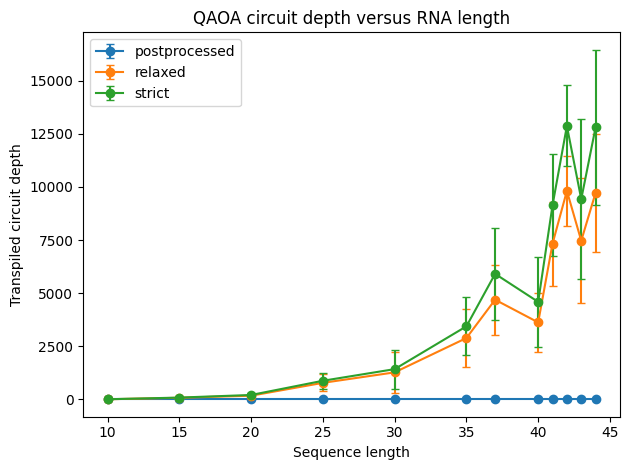

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/08_num_qubits.png


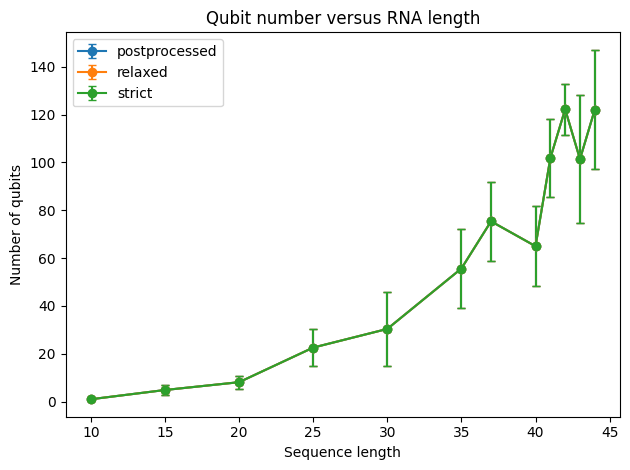

In [ ]:
for mean_column, std_column, y_label, title, filename in [
    (
        "mean_circuit_depth",
        "std_circuit_depth",
        "Transpiled circuit depth",
        "QAOA circuit depth versus RNA length",
        "07_circuit_depth.png",
    ),
    (
        "mean_num_qubits",
        "std_num_qubits",
        "Number of qubits",
        "Qubit number versus RNA length",
        "08_num_qubits.png",
    ),
]:
    fig, ax = plot_metric_by_length(
        length_summary_df,
        mean_column=mean_column,
        std_column=std_column,
        y_label=y_label,
        title=title,
        backend_modes=("ibm",),
    )
    save_figure(fig, filename)
    plt.show()

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/09_aer_optimization_runtime.png


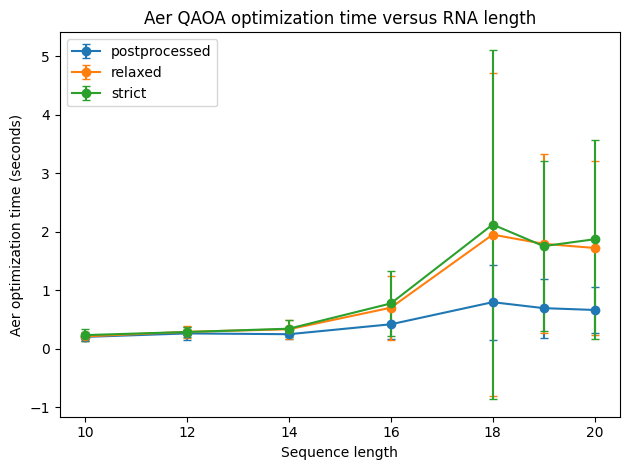

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/10_aer_sampling_runtime.png


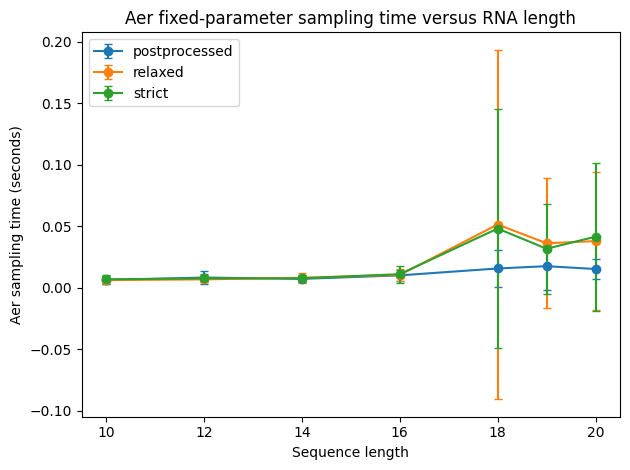

In [ ]:
aer_runtime_rows = run_metadata_df[
    run_metadata_df["backend_mode"] == "aer"
].copy()

aer_runtime_summary_df = (
    aer_runtime_rows.groupby(
        ["length", "variant", "backend_mode", "backend_name"],
        as_index=False,
    )
    .agg(
        mean_optimization_seconds=("optimization_runtime_seconds", "mean"),
        std_optimization_seconds=("optimization_runtime_seconds", "std"),
        mean_sampling_seconds=("sampling_runtime_seconds", "mean"),
        std_sampling_seconds=("sampling_runtime_seconds", "std"),
    )
)

for mean_column, std_column, y_label, title, filename in [
    (
        "mean_optimization_seconds",
        "std_optimization_seconds",
        "Aer optimization time (seconds)",
        "Aer QAOA optimization time versus RNA length",
        "09_aer_optimization_runtime.png",
    ),
    (
        "mean_sampling_seconds",
        "std_sampling_seconds",
        "Aer sampling time (seconds)",
        "Aer fixed-parameter sampling time versus RNA length",
        "10_aer_sampling_runtime.png",
    ),
]:
    fig, ax = plot_metric_by_length(
        aer_runtime_summary_df,
        mean_column=mean_column,
        std_column=std_column,
        y_label=y_label,
        title=title,
        backend_modes=("aer",),
    )
    save_figure(fig, filename)
    plt.show()

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/11_ibm_qpu_runtime.png


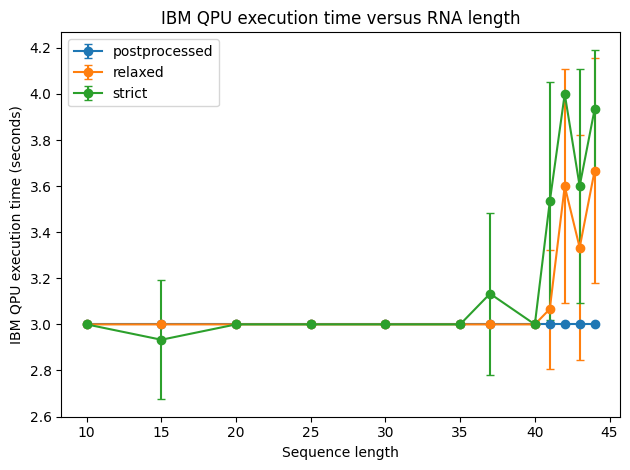

In [ ]:
ibm_runtime_rows = run_metadata_df[
    (run_metadata_df["backend_mode"] == "ibm")
    & run_metadata_df["sampling_runtime_seconds"].notna()
].copy()

ibm_runtime_summary_df = (
    ibm_runtime_rows.groupby(
        ["length", "variant", "backend_mode", "backend_name"],
        as_index=False,
    )
    .agg(
        mean_sampling_seconds=("sampling_runtime_seconds", "mean"),
        std_sampling_seconds=("sampling_runtime_seconds", "std"),
    )
)
fig, ax = plot_metric_by_length(
    ibm_runtime_summary_df,
    mean_column="mean_sampling_seconds",
    std_column="std_sampling_seconds",
    y_label="IBM QPU execution time (seconds)",
    title="IBM QPU execution time versus RNA length",
    backend_modes=("ibm",),
)
save_figure(fig, "11_ibm_qpu_runtime.png")
plt.show()

## 8. Compact final table


In [ ]:
final_columns = [
    "length",
    "variant",
    "backend_mode",
    "num_sequences",
    "mean_num_variables",
    "mean_num_quadratic_terms",
    "mean_num_qubits",
    "mean_weighted_raw_validity",
    "mean_weighted_stems_removed",
    "mean_retained_probability_mass",
    "mean_energy_gap",
    "mean_pair_f1",
    "mean_circuit_depth",
    "mean_sampling_seconds",
]

display(length_summary_df[final_columns])


,length,variant,backend_mode,num_sequences,mean_num_variables,mean_num_quadratic_terms,mean_num_qubits,mean_weighted_raw_validity,mean_weighted_stems_removed,mean_retained_probability_mass,mean_energy_gap,mean_pair_f1,mean_circuit_depth,mean_sampling_seconds
0,10,postprocessed,aer,30,1.600000,0.000000,1.600000,0.500391,0.599512,1.0,2.833333,0.000000,2.000000,0.006363
1,12,postprocessed,aer,30,3.700000,0.000000,3.700000,0.169417,2.330599,1.0,1.983333,0.166667,2.000000,0.008309
2,14,postprocessed,aer,30,4.700000,0.000000,4.700000,0.070703,3.268701,1.0,2.023333,0.200000,2.000000,0.007267
3,16,postprocessed,aer,30,7.566667,0.000000,7.566667,0.100260,5.347591,1.0,1.020000,0.466667,2.000000,0.010085
4,18,postprocessed,aer,30,11.733333,0.000000,11.733333,0.000065,8.666520,1.0,1.686667,0.295238,2.000000,0.015699
5,19,postprocessed,aer,30,11.900000,0.000000,11.900000,0.000537,8.625000,1.0,1.330000,0.425541,2.000000,0.017559
6,20,postprocessed,aer,30,11.933333,0.000000,11.933333,0.000033,9.088590,1.0,1.110000,0.532804,2.000000,0.015262
7,10,relaxed,aer,30,1.600000,0.566667,1.600000,0.904492,0.116113,1.0,1.470000,0.466667,3.100000,0.006218
8,12,relaxed,aer,30,3.700000,5.400000,3.700000,0.558870,0.580029,1.0,0.533333,0.800000,7.533333,0.006858
9,14,relaxed,aer,30,4.700000,8.700000,4.700000,0.507292,0.775374,1.0,0.316667,0.900000,8.900000,0.008172


## 9. Paired hardware comparisons

Each difference is calculated for the same `sequence_id`. The plotted point is the mean paired difference at a sequence length, and the error bar is one standard deviation across matched sequences. Differences are `variant_b - variant_a`.


In [ ]:
def paired_variant_differences(
    dataframe,
    value_column,
    variant_a,
    variant_b,
):
    hardware_df = dataframe[
        (dataframe["backend_mode"] == "ibm")
        & dataframe["variant"].isin([variant_a, variant_b])
    ]

    paired_df = hardware_df.pivot_table(
        index=["sequence_id", "length"],
        columns="variant",
        values=value_column,
        aggfunc="mean",
    ).dropna(subset=[variant_a, variant_b])

    return pd.DataFrame(
        {
            "difference": paired_df[variant_b] - paired_df[variant_a],
            "length": paired_df.index.get_level_values("length"),
        }
    ).reset_index(drop=True)


def plot_paired_differences(
    difference_df,
    *,
    y_label,
    title,
):
    summary_df = (
        difference_df.groupby("length", as_index=False)
        .agg(
            mean_difference=("difference", "mean"),
            std_difference=("difference", "std"),
        )
        .sort_values("length")
    )
    summary_df["std_difference"] = summary_df["std_difference"].fillna(0.0)

    fig, ax = plt.subplots()
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.errorbar(
        summary_df["length"],
        summary_df["mean_difference"],
        yerr=summary_df["std_difference"],
        marker="o",
        capsize=3,
    )
    ax.set_xlabel("Sequence length")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    fig.tight_layout()

    return fig, ax


Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/12_probability_weighted_stems_removed_relaxed_minus_strict.png


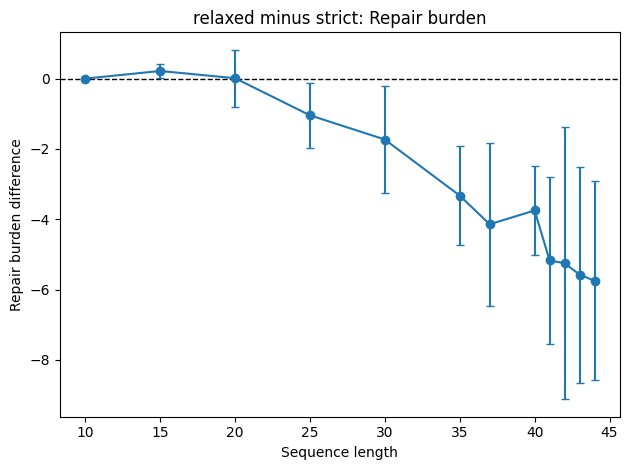

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/12_circuit_depth_relaxed_minus_strict.png


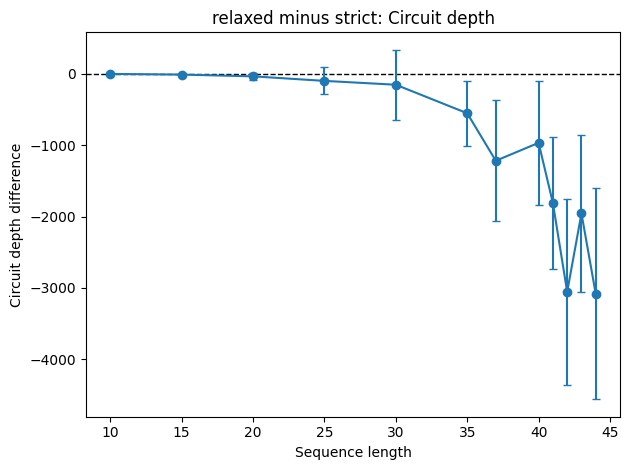

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/12_energy_gap_relaxed_minus_strict.png


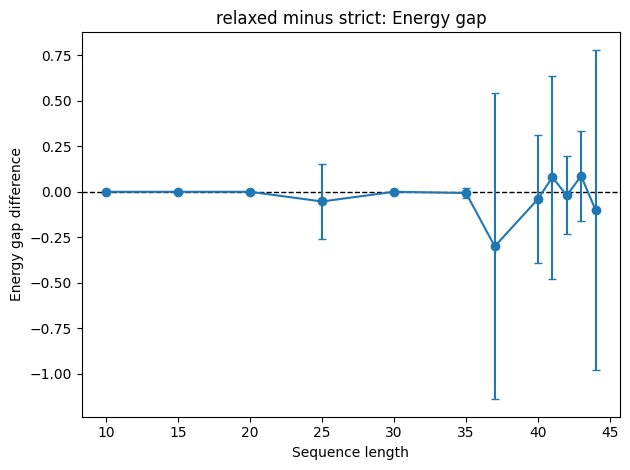

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/12_pair_f1_relaxed_minus_strict.png


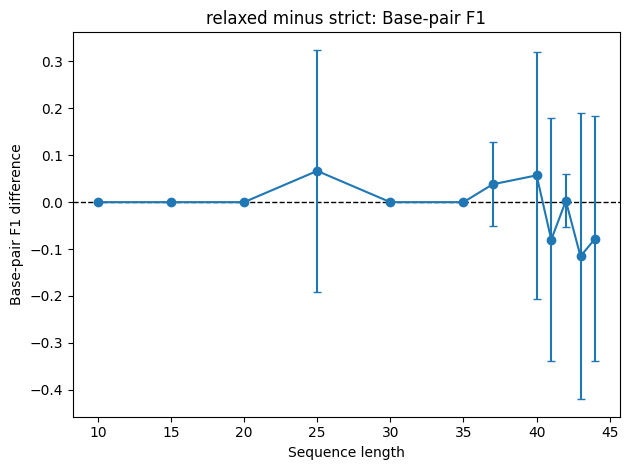

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/12_probability_weighted_raw_validity_relaxed_minus_strict.png


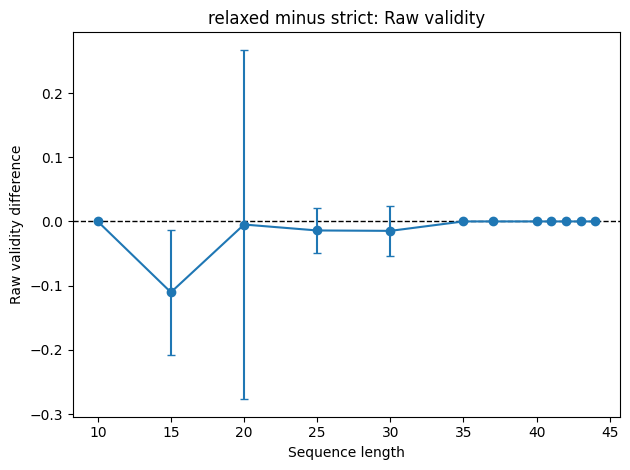

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/12_probability_weighted_stems_removed_postprocessed_minus_relaxed.png


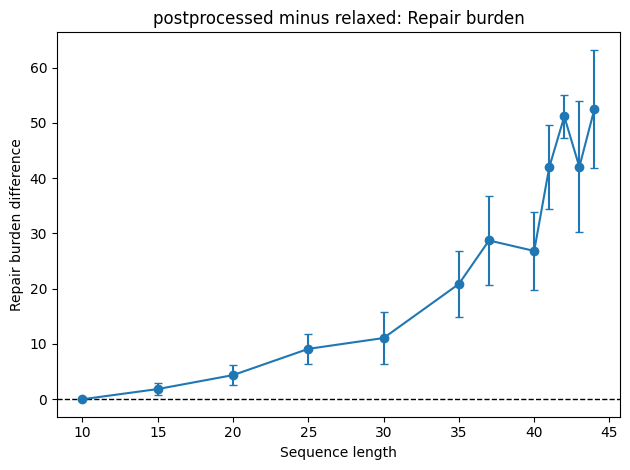

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/12_circuit_depth_postprocessed_minus_relaxed.png


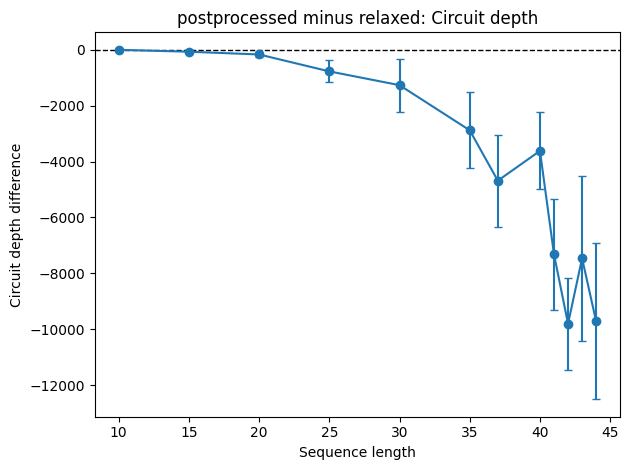

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/12_energy_gap_postprocessed_minus_relaxed.png


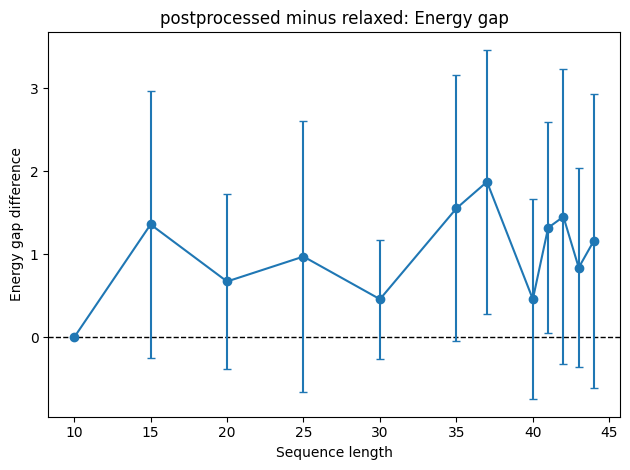

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/12_pair_f1_postprocessed_minus_relaxed.png


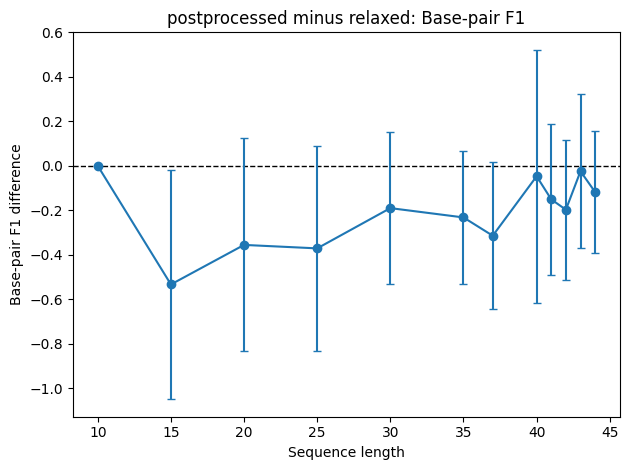

Saved figure: /content/drive/MyDrive/Colab Notebooks/WISER_Moderna_02/figures/12_probability_weighted_raw_validity_postprocessed_minus_relaxed.png


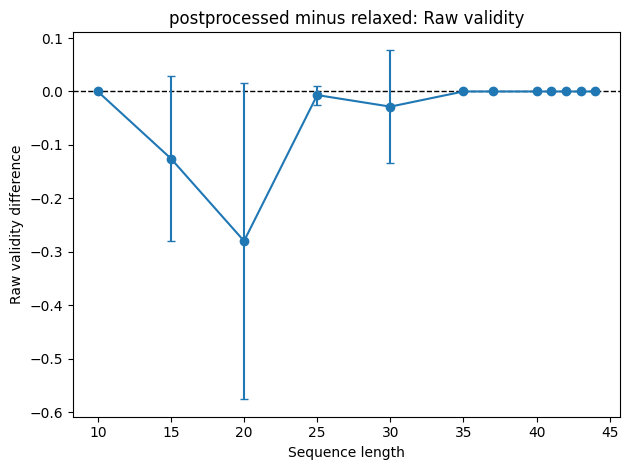

In [ ]:
paired_metrics = {
    "probability_weighted_stems_removed": "Repair burden",
    "circuit_depth": "Circuit depth",
    "energy_gap": "Energy gap",
    "pair_f1": "Base-pair F1",
    "probability_weighted_raw_validity": "Raw validity",
}

variant_pairs = [
    ("strict", "relaxed"),
    ("relaxed", "postprocessed"),
]

for variant_a, variant_b in variant_pairs:
    for column, label in paired_metrics.items():
        difference_df = paired_variant_differences(
            per_run_summary_df,
            value_column=column,
            variant_a=variant_a,
            variant_b=variant_b,
        )

        if difference_df.empty:
            continue

        fig, ax = plot_paired_differences(
            difference_df,
            y_label=f"{label} difference",
            title=f"{variant_b} minus {variant_a}: {label}",
        )

        filename = (f"12_{column}_{variant_b}_minus_{variant_a}.png")
        save_figure(fig, filename)

        plt.show()
